
0: 384x640 5 lines, 1 board, 5 Os, 5 LLs, 5 ZRs, 5 ZLs, 5 Ts, 5 LRs, 11.2ms
Speed: 1.5ms preprocess, 11.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
使用设备: cuda
类别:O 主峰：115 灰度级, 范围 [91, 129]


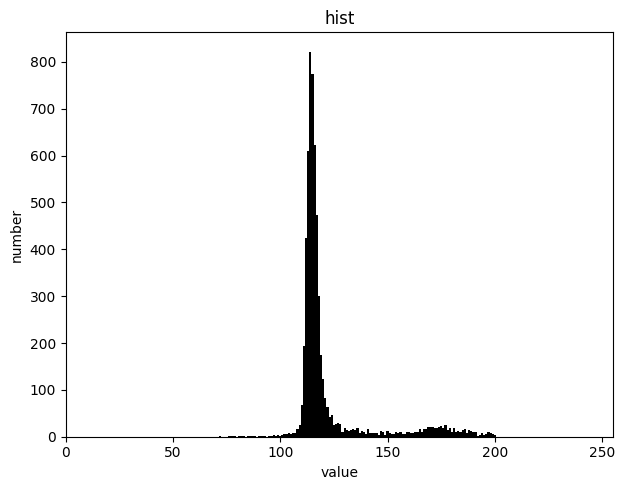

类别:ZR 主峰：85 灰度级, 范围 [63, 99]


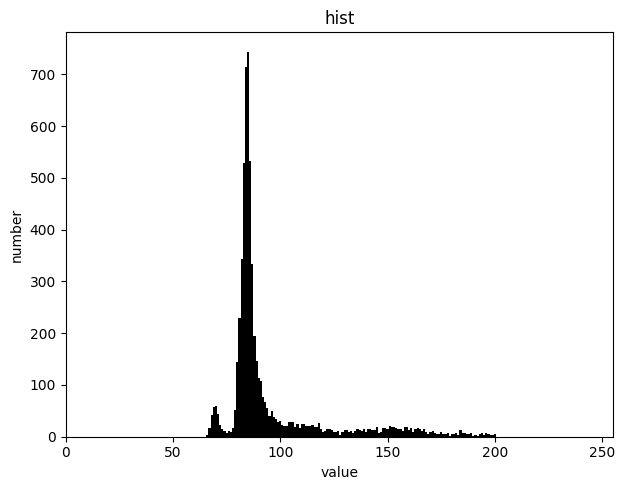

类别:LR 主峰：69 灰度级, 范围 [58, 88]


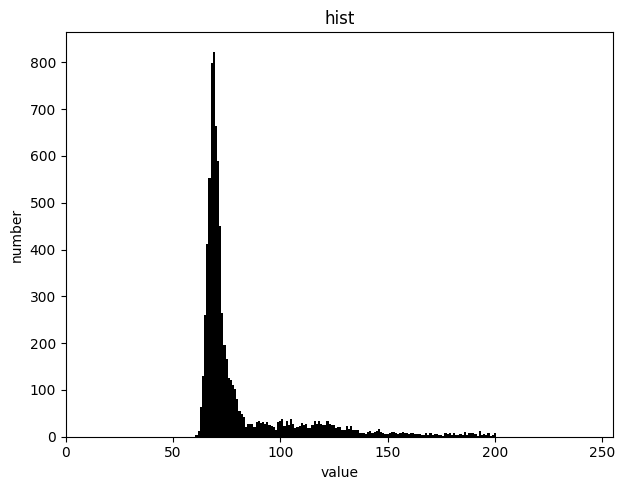

类别:LR 主峰：67 灰度级, 范围 [57, 83]


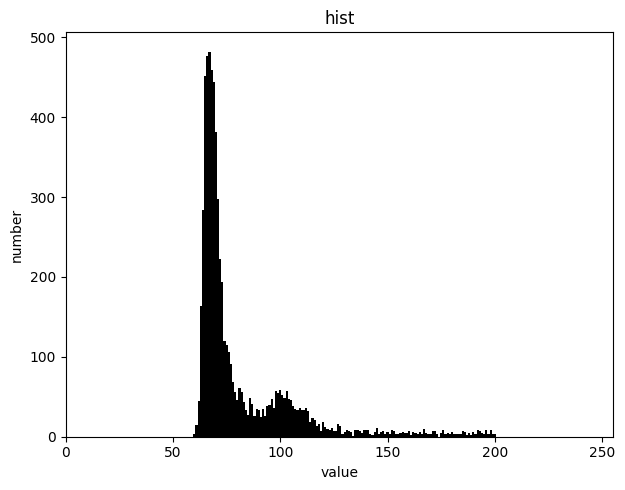

类别:LL 主峰：149 灰度级, 范围 [66, 164]


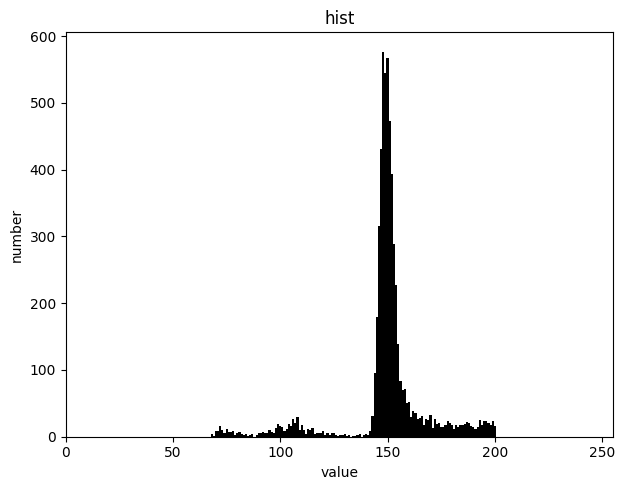

类别:O 主峰：103 灰度级, 范围 [91, 116]


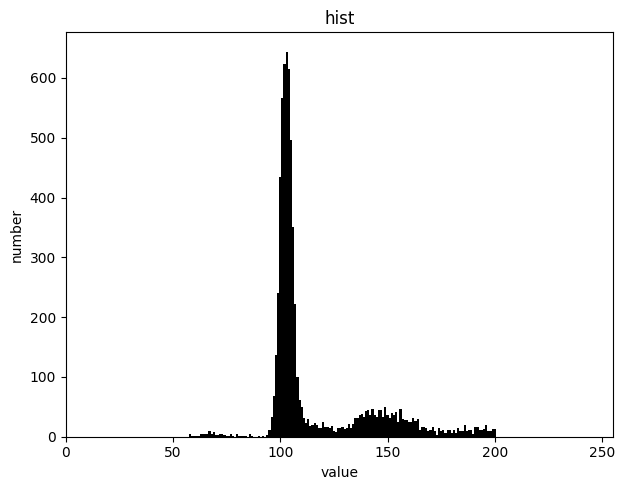

类别:line 主峰：72 灰度级, 范围 [62, 86]


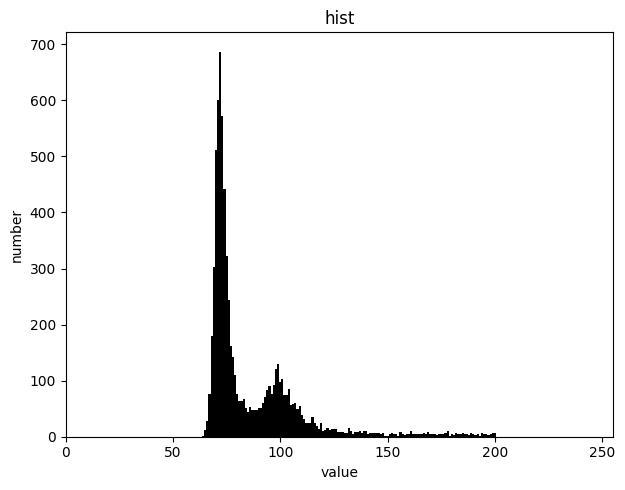

类别:T 主峰：60 灰度级, 范围 [50, 74]


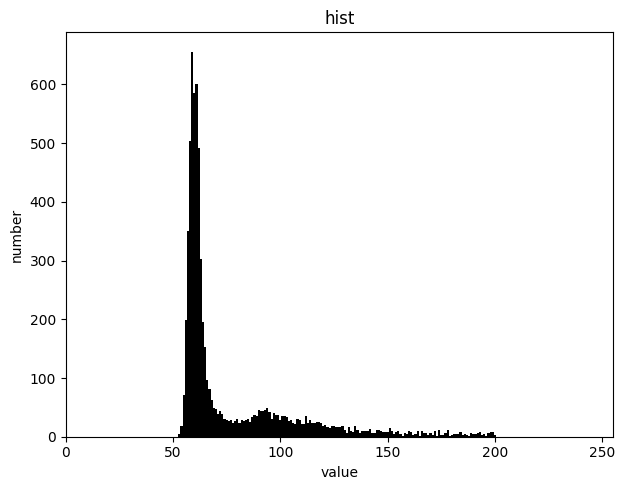

类别:T 主峰：67 灰度级, 范围 [57, 83]


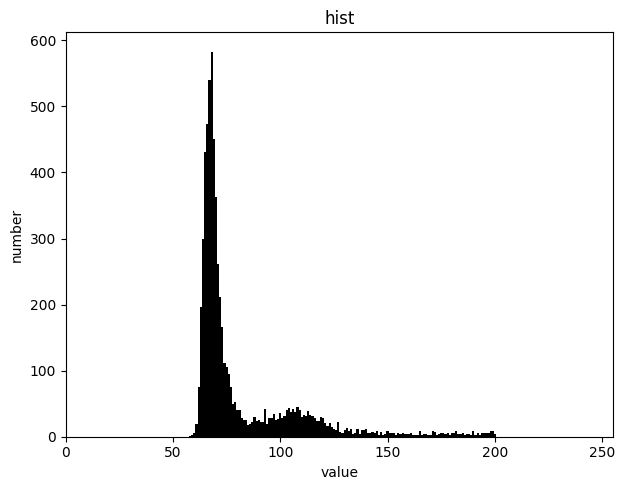

类别:ZR 主峰：64 灰度级, 范围 [47, 78]


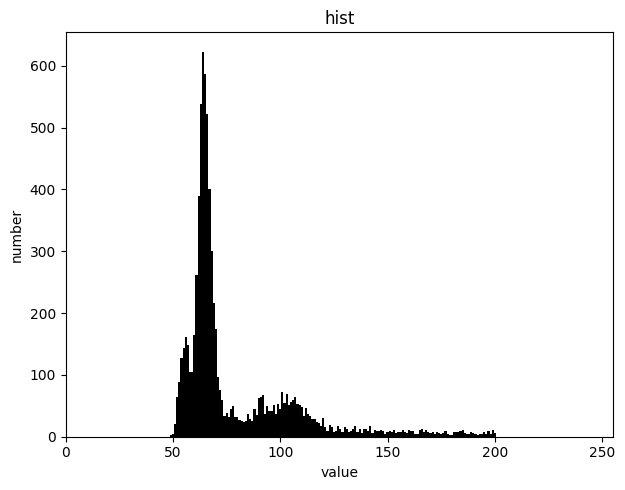

类别:O 主峰：92 灰度级, 范围 [51, 105]


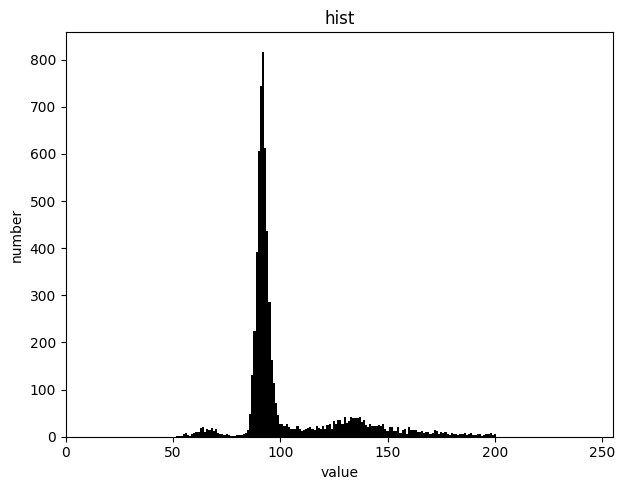

类别:ZL 主峰：70 灰度级, 范围 [59, 85]


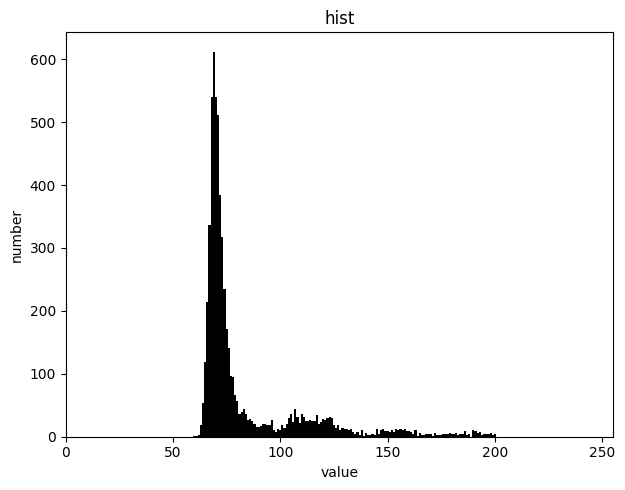

类别:T 主峰：68 灰度级, 范围 [58, 82]


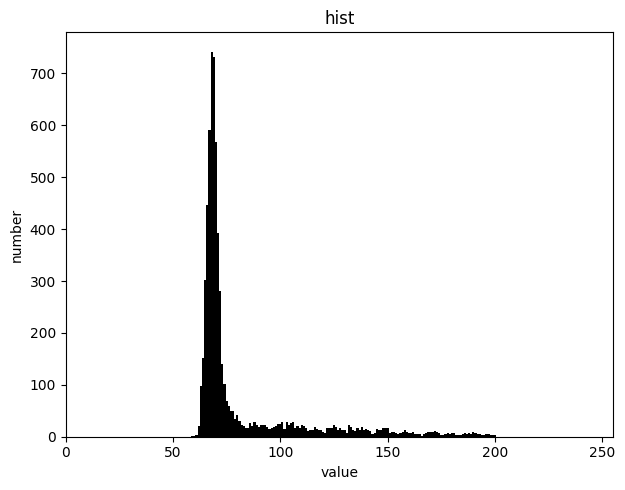

类别:ZL 主峰：64 灰度级, 范围 [54, 77]


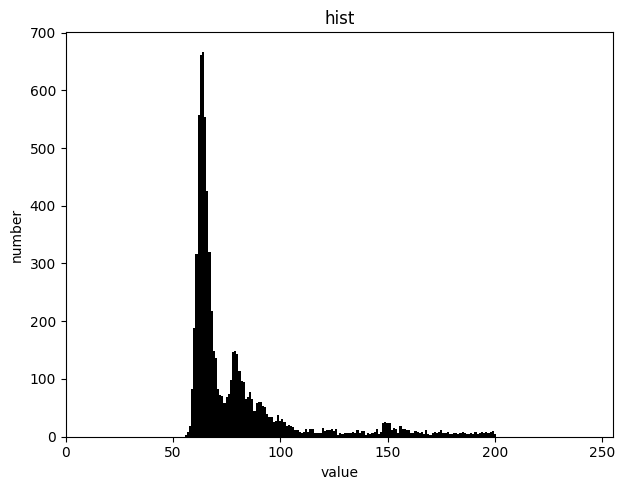

类别:ZL 主峰：58 灰度级, 范围 [48, 73]


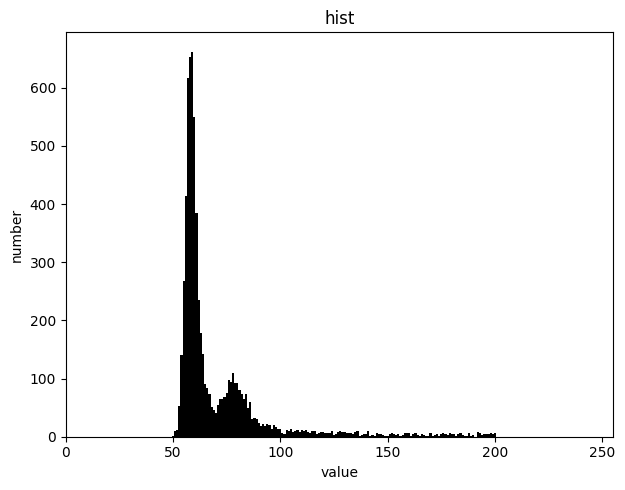

类别:ZR 主峰：68 灰度级, 范围 [57, 83]


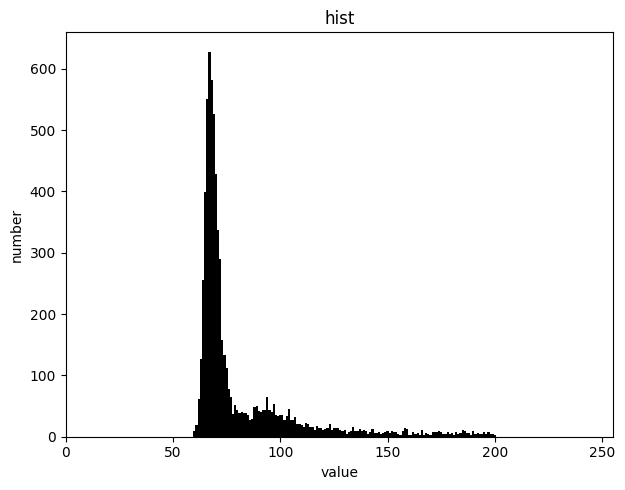

类别:line 主峰：70 灰度级, 范围 [61, 85]


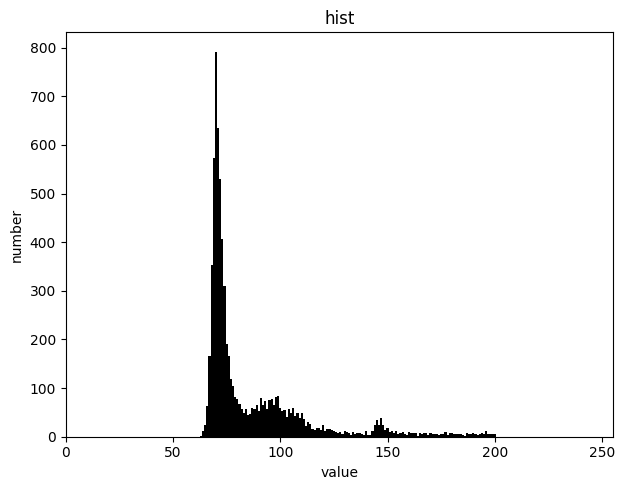

类别:ZR 主峰：79 灰度级, 范围 [57, 93]


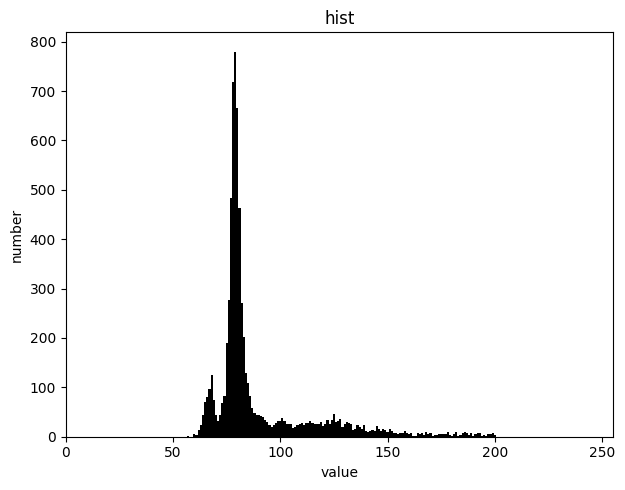

类别:ZR 主峰：72 灰度级, 范围 [52, 86]


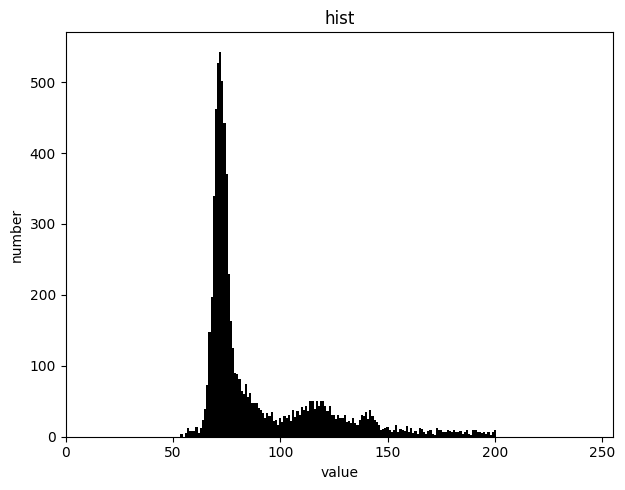

类别:LL 主峰：138 灰度级, 范围 [93, 152]


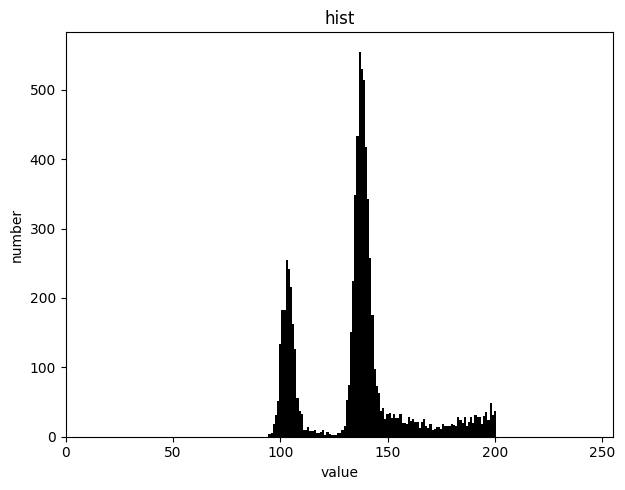

类别:LR 主峰：69 灰度级, 范围 [58, 83]


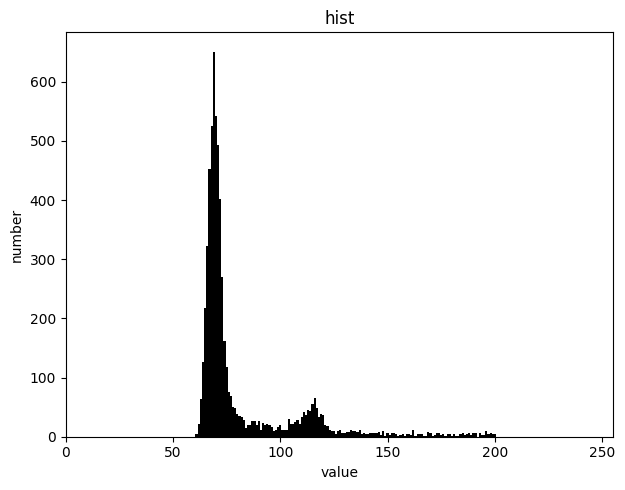

类别:O 主峰：105 灰度级, 范围 [57, 118]


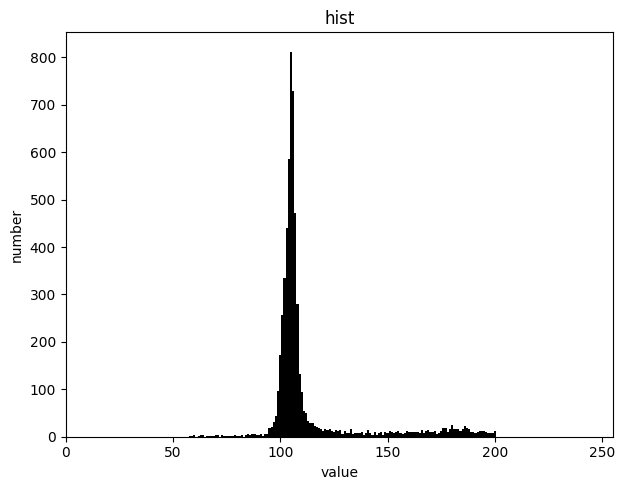

类别:O 主峰：104 灰度级, 范围 [95, 117]


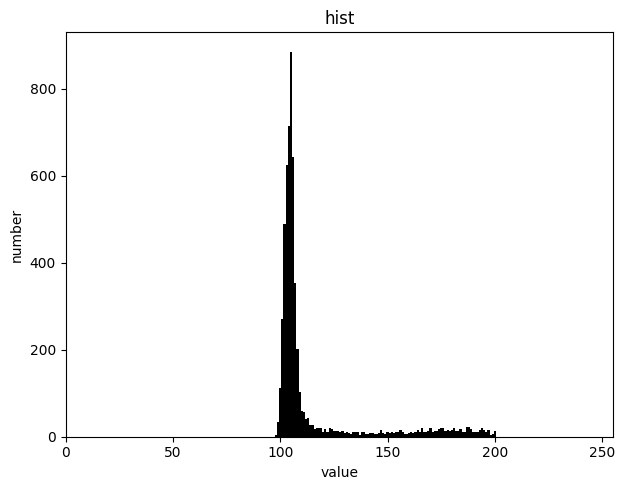

类别:LR 主峰：57 灰度级, 范围 [48, 70]


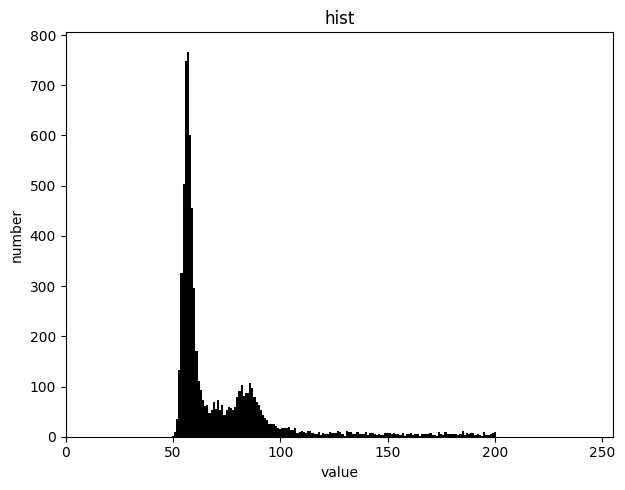

类别:T 主峰：69 灰度级, 范围 [58, 86]


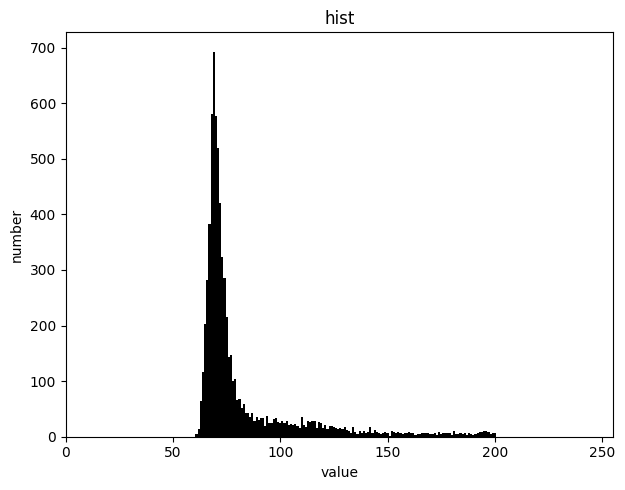

类别:LL 主峰：144 灰度级, 范围 [70, 158]


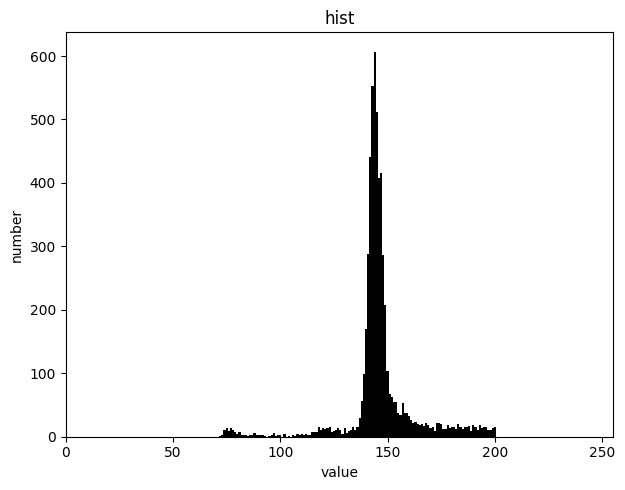

类别:ZL 主峰：68 灰度级, 范围 [57, 82]


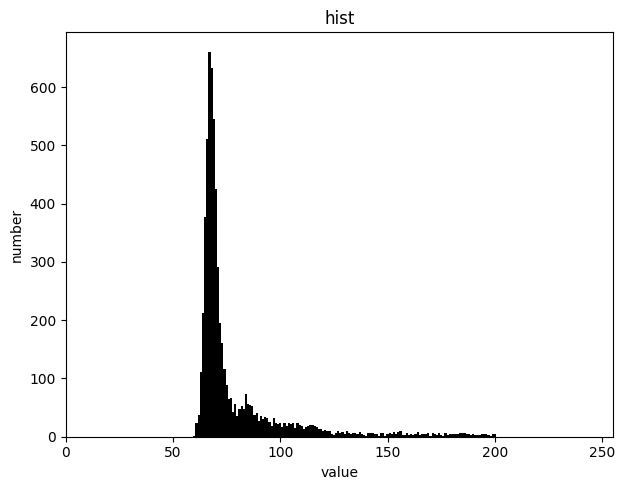

类别:T 主峰：61 灰度级, 范围 [52, 75]


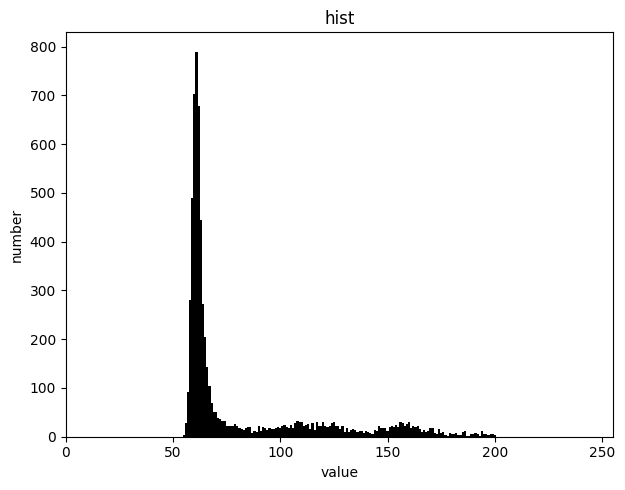

类别:line 主峰：72 灰度级, 范围 [63, 86]


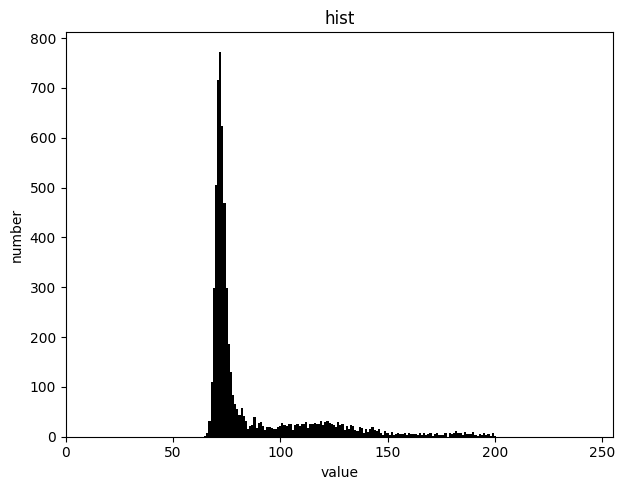

类别:line 主峰：67 灰度级, 范围 [51, 81]


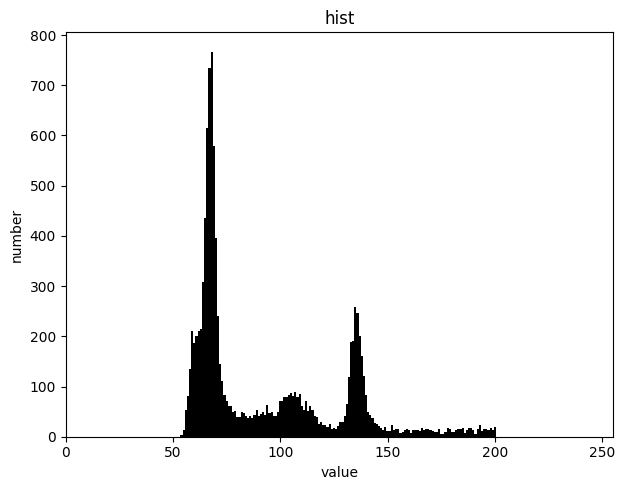

类别:LL 主峰：137 灰度级, 范围 [58, 151]


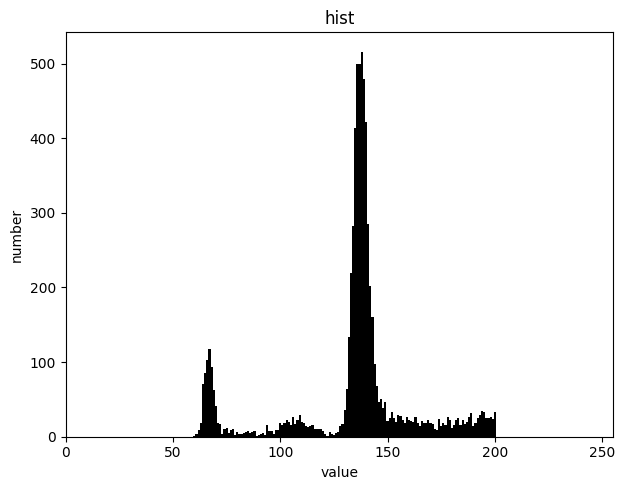

类别:LL 主峰：163 灰度级, 范围 [143, 178]


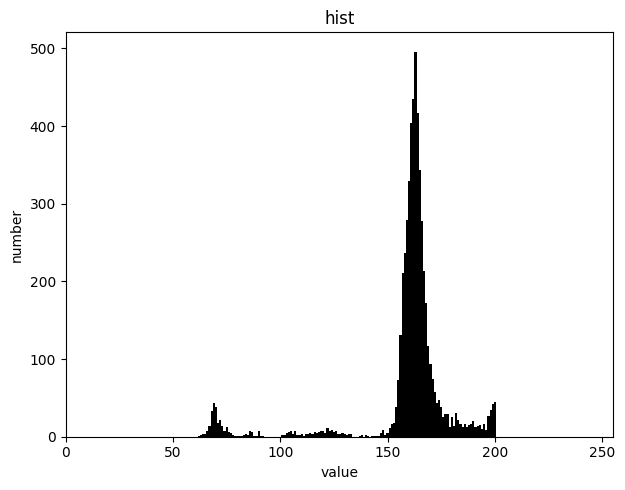

类别:line 主峰：71 灰度级, 范围 [62, 84]


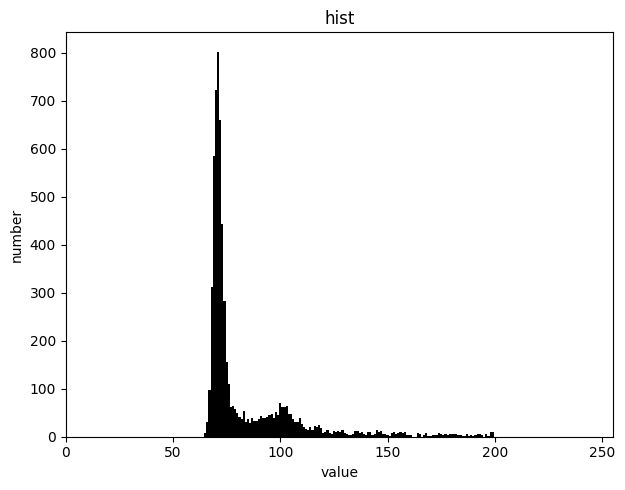

类别:ZL 主峰：55 灰度级, 范围 [46, 74]


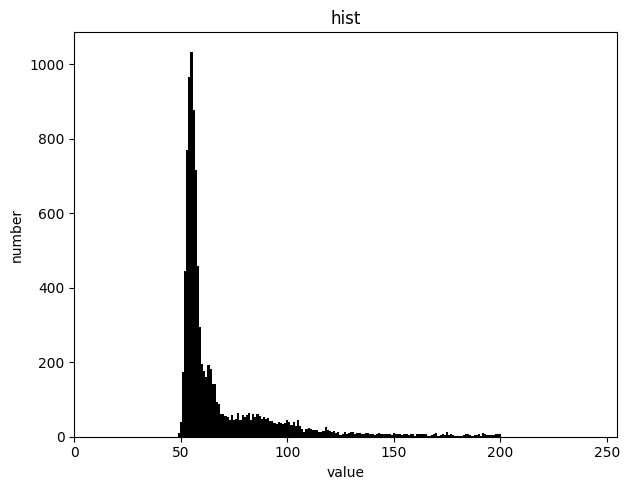

类别:LR 主峰：57 灰度级, 范围 [46, 72]


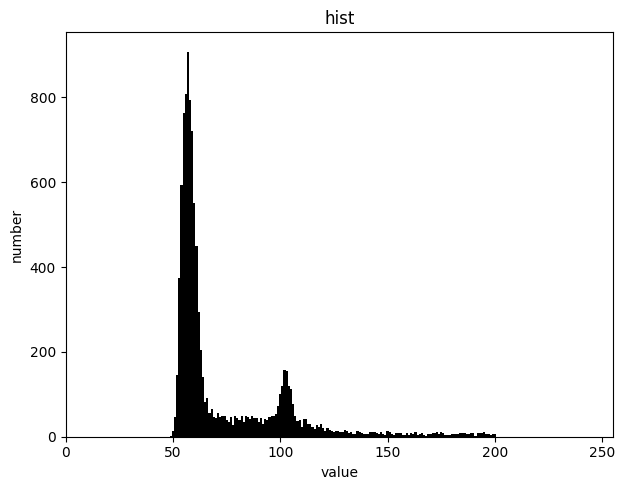

In [2]:
import torch
import cv2
import numpy as np
from image_process_lib.Place_optimization import get_all_cube, make_list, put_fenlei,cube_pocess,optimize_block_assignment,get_cube_location,get_put_pose
from image_process_lib.block_detection import get_mask, coreect_LL_location
from image_process_lib.template_match.template_match import get_rect
from image_process_lib.point_calibration import ArmCalibrator, x_predict,y_predict,z_predict
from image_process_lib.board_detect import board_detect
from ultralytics import YOLO


model_path="/home/zhl/SingleArmTetris/SingleArmTetris/src/competition/model/best5.14.pt"
model=YOLO(model_path)
img_bgr = cv2.imread("/home/zhl/桌面/board_bgr.jpg")
h, w = img_bgr.shape[:2]
img_bgr2=np.copy(img_bgr)#复制一个数组，我们会在检测到的图片中画黑框开辅助判断，但黑框会影响颜色分割，所以复制一个数组，img_bgr用来检测画黑框，img_bgr2用来颜色分割
result = model(img_bgr,iou=0.5,conf=0.45)#yolo检测
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")
for det in result[0].boxes.data.tolist():
    x1, y1, x2, y2, score, cid = det#取出识别结果
    category = model.names[int(cid)]#类别
    if(category=="board"):
        continue
    px=(x1+x2)/2        
    py=(y1+y2)/2
    cropped_img = img_bgr[int(y1)+3:int(y2)-3, int(x1)+3:int(x2)-3]#根据yolo的框取出图像
    mask=get_mask(cropped_img,category)#颜色分割，mask是分割的图片二值化图
    cv2.imshow("mask",mask)
    cv2.imshow("cropped_img",cropped_img)
    if(category=="line"):
        rect = get_rect(mask,150, 33,category,img_bgr2,x1,y1)
    elif(category=="O"):
        rect = get_rect(mask,71, 71,category,img_bgr2,x1,y1)
    else:
        rect = get_rect(mask,109, 71,category,img_bgr2,x1,y1)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    #根据最长的轮廓cnt来得到包含方块上表面的最小矩形框，进而得到中心点
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    # abs_box = box + [int(x1)+3, int(y1)+3]

    px=(int(rect[0][0])+int(x1)+3)
    py=(int(rect[0][1])+int(y1)+3)
    if(category=="LL" or category=="LR"):#L型方块要特殊处理，吸中间吸不起来
        px,py=coreect_LL_location(box,mask,rect)
        px=(px+int(x1)+3)
        py=(py+int(y1)+3)

    #给中心点画圈
    cv2.circle(img_bgr2,(px,py),3, (0, 0, 255), 2)


cv2.imshow('img_bgr2', img_bgr2)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [9]:
import cv2
img_gray = cv2.imread('/home/zhl/SingleArmTetris/SingleArmTetris/src/image_process/scripts/1.png', cv2.IMREAD_GRAYSCALE)          # 读取为灰度图
_, binary = cv2.threshold(img_gray, 80, 255, cv2.THRESH_BINARY)      # 阈值128，低于128变0，高于变255
cv2.imshow("1",binary)
cv2.imshow("img_gray",img_gray)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [2]:
import cv2

# ===== 参数设置 =====
IMAGE_PATH = "/home/zhl/SingleArmTetris/SingleArmTetris/src/image_process/scripts/image.png"          # 灰度图路径
OUTPUT_VIDEO = "/home/zhl/SingleArmTetris/SingleArmTetris/src/image_process/scripts/threshold_scan.mp4"
THRESH_MIN = 50                  # 扫描起点
THRESH_MAX = 180                 # 扫描终点
STEP = 1                         # 步长（越小渐变越细腻）
FPS = 8                          # 帧率（每秒几帧，越小变化越慢，观察更清楚）

# ===== 读取灰度图 =====
gray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if gray is None:
    raise FileNotFoundError(f"图像不存在：{IMAGE_PATH}")

h, w = gray.shape[:2]

# ===== 视频写入器 =====
fourcc = cv2.VideoWriter_fourcc(*'mp4v')          # MP4 编码
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, FPS, (w, h))

# ===== 遍历阈值，逐帧写入 =====
for thresh in range(THRESH_MIN, THRESH_MAX + 1, STEP):
    # 二值化：THRESH_BINARY 表示“大于阈值为 255，否则 0”
    _, binary = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    # 转成三通道（VideoWriter 要求彩色）
    frame = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    # 在画面左上角标出当前阈值
    cv2.putText(frame, f"Threshold = {thresh}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
    out.write(frame)

out.release()
cv2.destroyAllWindows()
print(f"视频已保存：{OUTPUT_VIDEO}")

视频已保存：/home/zhl/SingleArmTetris/SingleArmTetris/src/image_process/scripts/threshold_scan.mp4
